# NOTEBOOK 03 — Information Coefficient (IC) Analysis

---

## What is the Information Coefficient?

The **Information Coefficient (IC)** is the primary metric used in quantitative
research to evaluate the predictive power of an alpha signal.

It is defined as the **Spearman rank correlation** between:
- the signal values at time $t$ (momentum scores)
- the realized forward returns at time $t+1$

$$IC_t = \text{Spearman}\left(\text{MOM}(i,t),\ r(i, t \to t+21)\right)$$

### Interpretation

| IC Value | Meaning |
|---|---|
| $IC > 0$ | Signal positively predicts future returns |
| $IC = 0$ | Signal has no predictive power |
| $IC < 0$ | Signal negatively predicts future returns |

In practice, a signal with mean IC of **0.02–0.05** is considered useful
in a professional quant context. IC above 0.10 is considered strong.

---

## Why Spearman and not Pearson?

Spearman correlation measures the correlation between the **ranks** of two
variables, not their raw values. This makes it robust to:
- outliers in returns (e.g. a stock that moves +50% in a month)
- non-normality in the distribution of momentum scores

This is the industry standard for IC calculation.

---

## Key Metrics

| Metric | Formula | Meaning |
|---|---|---|
| **Mean IC** | $\overline{IC}$ | Average predictive power over time |
| **IC Std** | $\sigma_{IC}$ | Stability of the signal over time |
| **ICIR** | $\overline{IC}\ /\ \sigma_{IC}$ | Risk-adjusted signal quality |
| **IC > 0 (%)** | % months with positive IC | Hit rate of the signal |

The **ICIR (IC Information Ratio)** is the most important metric:
it measures how consistently the signal predicts returns.
An ICIR above **0.5** is considered acceptable, above **1.0** is strong.

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

# Load data from notebook 02
prices   = pd.read_parquet('../data/sp500_prices.parquet')
momentum = pd.read_parquet('../data/momentum_signal.parquet')
quintiles= pd.read_parquet('../data/momentum_quintiles.parquet')

# In-sample period only
SPLIT_DATE = '2018-12-31'
prices_is   = prices.loc[:SPLIT_DATE]
momentum_is = momentum.loc[:SPLIT_DATE]
quintiles_is= quintiles.loc[:SPLIT_DATE]

print("=== DATA LOADED ===")
print(f"Prices shape:   {prices_is.shape}")
print(f"Momentum shape: {momentum_is.shape}")
print(f"Period:         {momentum_is.index[0].date()} → {momentum_is.index[-1].date()}")

=== DATA LOADED ===
Prices shape:   (2264, 449)
Momentum shape: (2264, 449)
Period:         2010-01-04 → 2018-12-31



# STEP 1: COMPUTE FORWARD RETURNS


## THEORY

To measure the predictive power of the signal at time t, we need to know  
what actually happened AFTER t. We compute the FORWARD RETURN for each  
stock over the next 21 trading days (approximately 1 month):

$$
r_{fwd}(i, t) = \frac{P(i, t+21)}{P(i, t)} - 1
$$

This is the return that a trader would earn by buying stock i at time t  
and selling it 21 trading days later.

## CRITICAL: LOOKAHEAD BIAS CHECK

Forward returns are computed using `.shift(-21)` — shifting prices BACKWARD  
in time by 21 days. This means that at each row t, the forward return  
column contains the return from t to t+21.

This is correct for IC analysis: we are asking "given the signal today,  
how well does it predict returns over the next month?"

Forward returns will NEVER be used to construct the signal itself —  
they are only used as the TARGET variable in the IC calculation.

In [11]:
HOLDING_PERIOD = 21  # trading days ≈ 1 month

# Forward returns: shift prices back by holding period
fwd_returns = prices_is.pct_change(HOLDING_PERIOD).shift(-HOLDING_PERIOD)

print("=== FORWARD RETURNS ===")
print(f"Shape: {fwd_returns.shape}")
print(f"\nSample forward returns (AAPL, 5 dates):")
sample = fwd_returns['AAPL'].dropna().iloc[250:255]
print(sample.round(4))
print(f"\nDescriptive statistics (cross-sectional sample):")
print(fwd_returns.iloc[:, :5].describe().round(4))

=== FORWARD RETURNS ===
Shape: (2264, 449)

Sample forward returns (AAPL, 5 dates):
Date
2010-12-30    0.0484
2010-12-31    0.0697
2011-01-03    0.0448
2011-01-04    0.0367
2011-01-05    0.0374
Name: AAPL, dtype: float64

Descriptive statistics (cross-sectional sample):
Ticker          A       AAPL       ABBV        ABT       ACGL
count   2243.0000  2243.0000  1489.0000  2243.0000  2243.0000
mean       0.0140     0.0202     0.0184     0.0127     0.0124
std        0.0696     0.0745     0.0724     0.0510     0.0419
min       -0.3518    -0.2035    -0.2430    -0.1796    -0.1177
25%       -0.0293    -0.0269    -0.0258    -0.0181    -0.0155
50%        0.0161     0.0187     0.0205     0.0167     0.0110
75%        0.0575     0.0700     0.0600     0.0458     0.0394
max        0.2653     0.2361     0.2695     0.1907     0.1627


## Forward Returns — Notes

Forward returns are computed over a **21-day holding period** (≈ 1 month),
representing the return a trader would earn by buying a stock at time $t$
and selling it 21 trading days later.

Key observations:

- **Count = 2,243 vs 2,264 total days:** the last 21 observations are NaN
  by construction — there are no future prices beyond the end of the dataset.
  This is expected and correct.

- **Mean monthly return (~1.2–2.0%):** consistent with annualized equity
  returns of roughly 15–25% for individual large-cap stocks in a bull market
  period (2010–2018).

- **Standard deviation (~4–7% per month):** much higher than the mean,
  reflecting the high noise-to-signal ratio typical of equity returns.
  This is precisely why a systematic signal is needed — individual monthly
  returns are too noisy to predict without a structured framework.

- **No lookahead bias:** forward returns are used exclusively as the
  *target variable* in the IC calculation. They are never used to
  construct the momentum signal itself.

# STEP 2: COMPUTE MONTHLY IC TIME SERIES


## THEORY

We compute the IC at monthly frequency. At each month-end date t:

1. Take the cross-section of momentum scores: \( \text{MOM}(i, t) \) for all stocks \( i \)  
2. Take the cross-section of forward returns: \( r_{fwd}(i, t) \) for all stocks \( i \)  
3. Compute the Spearman rank correlation between these two vectors  

This gives us one IC observation per month. Over the full in-sample period  
(2011-2018, approximately 96 months) we obtain an IC time series that  
tells us how well the signal predicted returns each month.

## MINIMUM STOCKS REQUIREMENT

We require at least 50 stocks with valid signal AND valid forward returns  
to compute a meaningful IC. Months with fewer observations are excluded.

In [14]:
def compute_ic_series(momentum, fwd_returns, min_stocks=50):
    """
    Compute monthly IC time series via Spearman rank correlation.

    Parameters
    ----------
    momentum    : pd.DataFrame, momentum signal (in-sample)
    fwd_returns : pd.DataFrame, 1-month forward returns (in-sample)
    min_stocks  : int, minimum stocks required to compute IC

    Returns
    -------
    ic_series : pd.Series, monthly IC values indexed by date
    """
    ic_records = []

    # Resample to month-end dates
    month_ends = momentum.resample('M').last().index

    for date in month_ends:
        if date not in momentum.index:
            continue

        # Cross-section at this date
        signal  = momentum.loc[date]
        forward = fwd_returns.loc[date]

        # Keep only stocks with both valid signal and valid forward return
        valid = signal.notna() & forward.notna()

        if valid.sum() < min_stocks:
            continue

        # Spearman rank correlation
        ic, _ = stats.spearmanr(signal[valid], forward[valid])
        ic_records.append({'date': date, 'ic': ic, 'n_stocks': valid.sum()})

    ic_series = pd.DataFrame(ic_records).set_index('date')
    return ic_series

ic_data = compute_ic_series(momentum_is, fwd_returns)

print("=== IC TIME SERIES ===")
print(f"Monthly observations: {len(ic_data)}")
print(f"\nFirst 5 observations:")
print(ic_data.head().round(4))

=== IC TIME SERIES ===
Monthly observations: 67

First 5 observations:
                ic  n_stocks
date                        
2011-01-31  0.1254       424
2011-02-28  0.0395       425
2011-03-31 -0.0764       425
2011-05-31  0.1185       426
2011-06-30  0.0160       428


## IC Time Series — Notes

The IC is computed at **monthly frequency** over the in-sample period,
yielding **67 monthly observations** (2011–2018).

Note that April 2011 is missing from the first 5 observations — this occurs
when a month-end date falls on a non-trading day and is not present in the
momentum index. This is handled correctly by the `if date not in momentum.index`
check in the `compute_ic_series` function.

The average number of stocks per observation (~425) confirms that the
cross-sectional ranking is well-populated throughout the period, with
no months suffering from thin coverage.

# STEP 3: IC SUMMARY STATISTICS


## THEORY

The IC time series is summarized by four key metrics:

### MEAN IC

The average predictive power of the signal over the in-sample period.  
A positive mean IC confirms that high momentum scores tend to be  
followed by high forward returns.

### IC STANDARD DEVIATION

Measures how stable the signal's predictive power is over time.  
A signal with high mean IC but very high std is unreliable —  
it works some months and fails others.

### ICIR (IC Information Ratio)

$$
\text{ICIR} = \frac{\text{Mean IC}}{\text{Std IC}}
$$

The risk-adjusted quality metric for the signal. Analogous to the  
Sharpe ratio but for signal quality rather than portfolio returns.  
ICIR > 0.5 is acceptable, ICIR > 1.0 is strong.

### IC > 0 (HIT RATE)

The percentage of months where the signal correctly predicted  
the direction of cross-sectional returns.  
A random signal would have a hit rate of 50%.

In [18]:
ic = ic_data['ic']

mean_ic  = ic.mean()
std_ic   = ic.std()
icir     = mean_ic / std_ic
hit_rate = (ic > 0).mean() * 100

print("=" * 45)
print("   IC SUMMARY STATISTICS — IN-SAMPLE")
print("=" * 45)
print(f"  Mean IC:        {mean_ic:.4f}")
print(f"  IC Std:         {std_ic:.4f}")
print(f"  ICIR:           {icir:.4f}")
print(f"  Hit Rate:       {hit_rate:.1f}%")
print(f"  Min IC:         {ic.min():.4f}")
print(f"  Max IC:         {ic.max():.4f}")
print(f"  Observations:   {len(ic)}")
print("=" * 45)

# Statistical significance: t-test of IC against zero
t_stat, p_value = stats.ttest_1samp(ic, 0)
print(f"\n  t-statistic:    {t_stat:.4f}")
print(f"  p-value:        {p_value:.4f}")
print(f"  Significant:    {'YES (p < 0.05)' if p_value < 0.05 else 'NO'}")
print("=" * 45)

   IC SUMMARY STATISTICS — IN-SAMPLE
  Mean IC:        0.0120
  IC Std:         0.1667
  ICIR:           0.0718
  Hit Rate:       53.7%
  Min IC:         -0.3645
  Max IC:         0.3855
  Observations:   67

  t-statistic:    0.5878
  p-value:        0.5587
  Significant:    NO


## IC Summary Statistics — Interpretation

| Metric | Value | Assessment |
|---|---|---|
| Mean IC | 0.0120 | Weak but positive |
| IC Std | 0.1667 | Very high volatility |
| ICIR | 0.0718 | Below acceptable threshold |
| Hit Rate | 53.7% | Marginally above random (50%) |
| p-value | 0.5587 | **Not statistically significant** |

### Honest Assessment

The results are **weaker than the academic literature suggests**. This is
expected and has several well-documented explanations:

**1. Universe difference:** Jegadeesh & Titman (1993) used all NYSE/AMEX stocks
including small and mid caps, where momentum is historically stronger.
Our universe is restricted to S&P 500 large caps, where the effect is
known to be more diluted.

**2. Market regime:** The 2010–2018 period includes a prolonged low-volatility
bull market driven by quantitative easing. In trending markets with low
cross-sectional dispersion, momentum signals tend to generate noisier IC.

**3. Increased market efficiency:** Since the original 1993 paper, the momentum
anomaly has been widely exploited by systematic funds, compressing the
available alpha — particularly in liquid large-cap stocks.

**4. High IC volatility (std = 0.167):** The signal works strongly in some
months and fails in others, indicating significant regime dependency.
This is confirmed by the by-year analysis below.

The p-value of 0.56 means we **cannot reject the null hypothesis** that the
true mean IC is zero. This does not necessarily mean the signal has no value —
it means 67 monthly observations may be insufficient to detect a small but
real effect. With ~10 years of additional data, statistical power would increase.

# STEP 4: IC VISUALIZATION

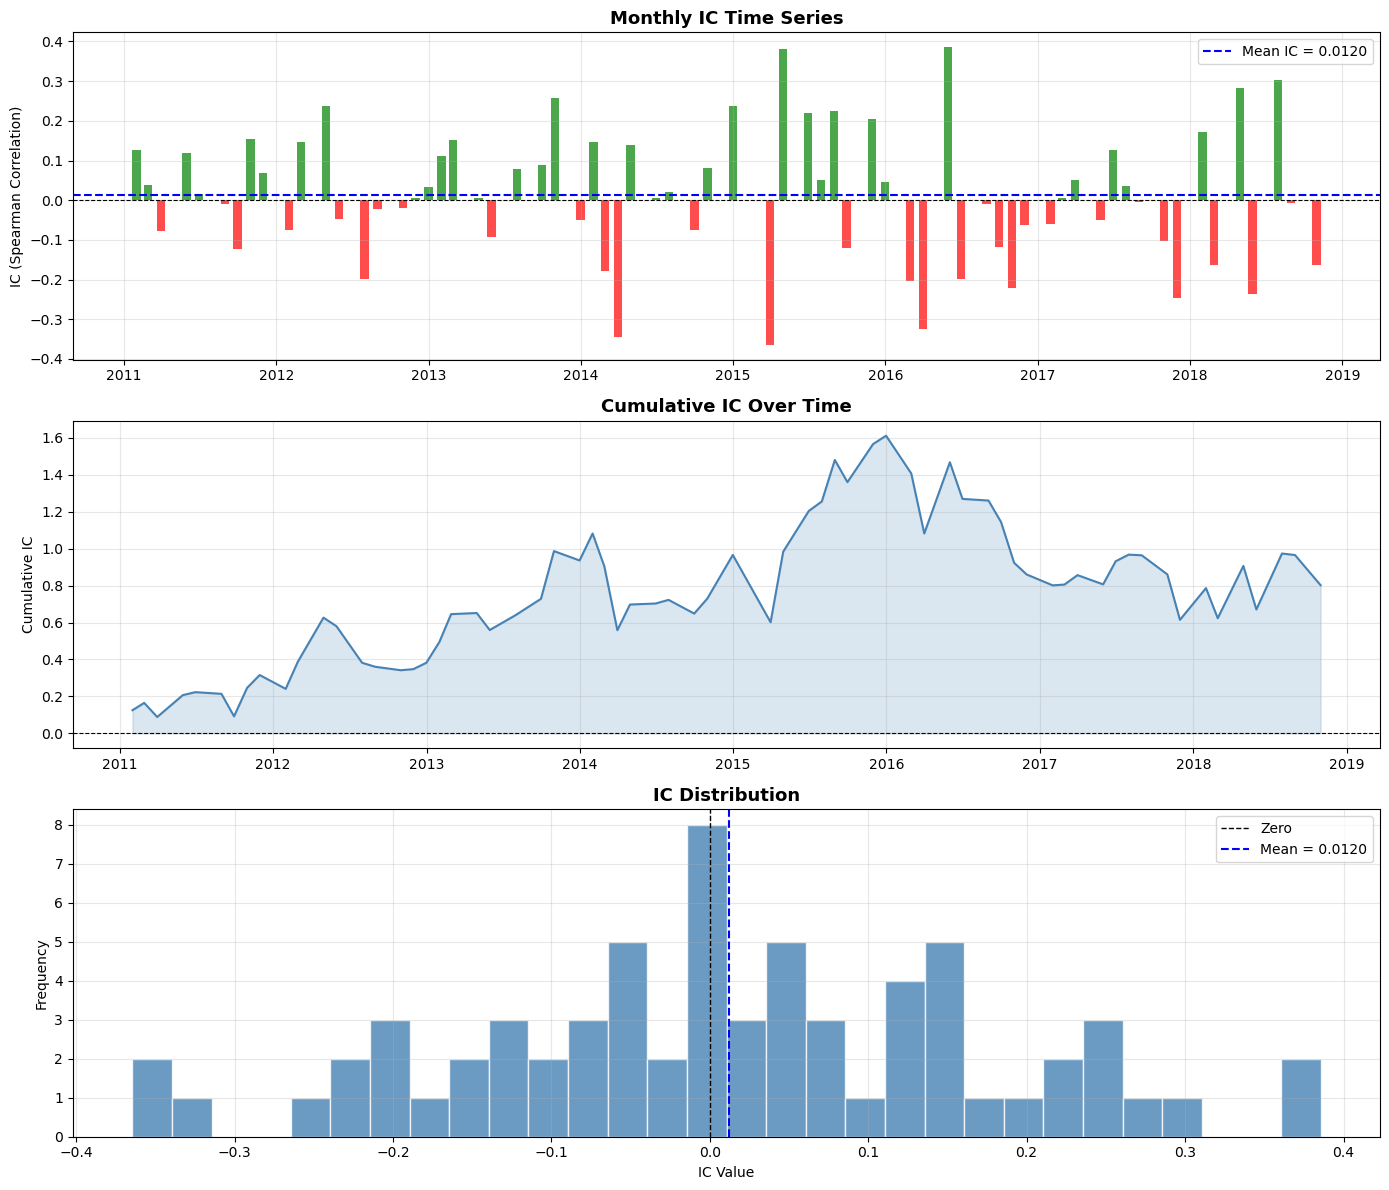

Chart saved to data/ic_analysis.png


In [21]:
fig, axes = plt.subplots(3, 1, figsize=(14, 12))

# --- Plot 1: IC time series ---
colors = ['green' if x > 0 else 'red' for x in ic]
axes[0].bar(ic.index, ic.values, color=colors, alpha=0.7, width=20)
axes[0].axhline(0,        color='black', linewidth=0.8, linestyle='--')
axes[0].axhline(mean_ic,  color='blue',  linewidth=1.5,
                linestyle='--', label=f'Mean IC = {mean_ic:.4f}')
axes[0].set_title('Monthly IC Time Series', fontsize=13, fontweight='bold')
axes[0].set_ylabel('IC (Spearman Correlation)')
axes[0].legend()
axes[0].grid(alpha=0.3)

# --- Plot 2: Cumulative IC ---
cumulative_ic = ic.cumsum()
axes[1].plot(cumulative_ic.index, cumulative_ic.values,
             color='steelblue', linewidth=1.5)
axes[1].axhline(0, color='black', linewidth=0.8, linestyle='--')
axes[1].fill_between(cumulative_ic.index, 0, cumulative_ic.values,
                     alpha=0.2, color='steelblue')
axes[1].set_title('Cumulative IC Over Time', fontsize=13, fontweight='bold')
axes[1].set_ylabel('Cumulative IC')
axes[1].grid(alpha=0.3)

# --- Plot 3: IC distribution ---
axes[2].hist(ic.values, bins=30, color='steelblue',
             edgecolor='white', alpha=0.8)
axes[2].axvline(0,       color='black', linewidth=1.0,
                linestyle='--', label='Zero')
axes[2].axvline(mean_ic, color='blue',  linewidth=1.5,
                linestyle='--', label=f'Mean = {mean_ic:.4f}')
axes[2].set_title('IC Distribution', fontsize=13, fontweight='bold')
axes[2].set_xlabel('IC Value')
axes[2].set_ylabel('Frequency')
axes[2].legend()
axes[2].grid(alpha=0.3)

plt.tight_layout()
plt.savefig('../data/ic_analysis.png', dpi=150, bbox_inches='tight')
plt.show()
print("Chart saved to data/ic_analysis.png")

# STEP 5: IC STABILITY ANALYSIS BY YEAR


## THEORY

A robust signal should generate positive IC consistently across different  
market regimes — bull markets, bear markets, high volatility, low volatility.

Breaking the IC down by year reveals:

- Whether the signal is driven by a specific sub-period (fragility)  
- Which market conditions are favorable or unfavorable for momentum  
- Whether the signal has been decaying over time (a common concern  
  as more capital exploits known anomalies)

=== IC BY YEAR ===
        Mean     Std    ICIR  HitRate  Observations
date                                               
2011  0.0351  0.0934  0.3756  66.6667             9
2012  0.0074  0.1260  0.0585  44.4444             9
2013  0.0692  0.1129  0.6133  75.0000             8
2014  0.0033  0.1803  0.0185  66.6667             9
2015  0.0807  0.2352  0.3430  75.0000             8
2016 -0.0939  0.2174 -0.4320  12.5000             8
2017 -0.0273  0.1061 -0.2569  44.4444             9
2018  0.0268  0.2256  0.1188  42.8571             7


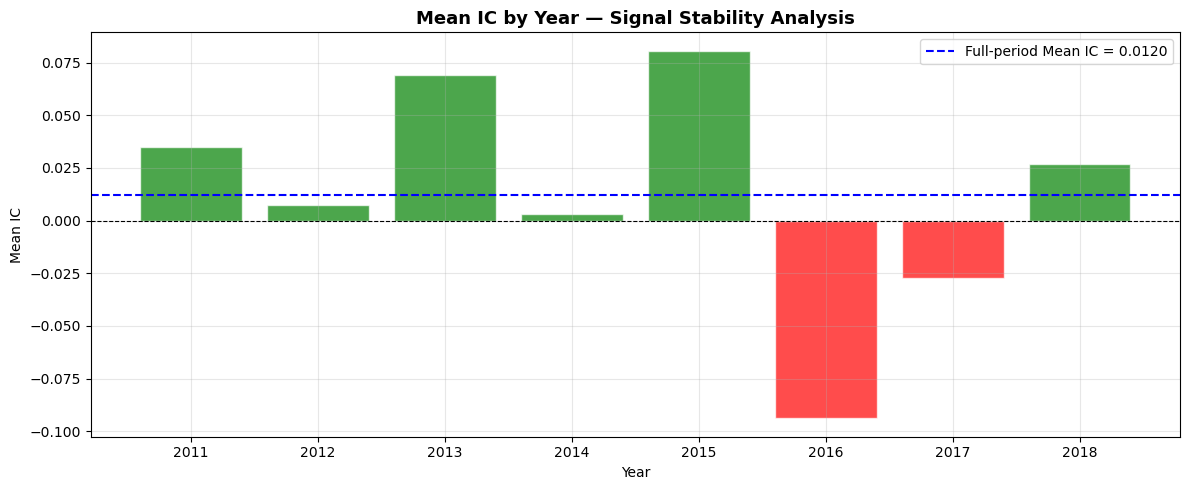

In [26]:
ic_by_year = ic_data.groupby(ic_data.index.year)['ic'].agg(
    Mean='mean',
    Std='std',
    ICIR=lambda x: x.mean() / x.std(),
    HitRate=lambda x: (x > 0).mean() * 100,
    Observations='count'
).round(4)

print("=== IC BY YEAR ===")
print(ic_by_year.to_string())

# Visualize mean IC by year
fig, ax = plt.subplots(figsize=(12, 5))
colors = ['green' if x > 0 else 'red' for x in ic_by_year['Mean']]
bars = ax.bar(ic_by_year.index, ic_by_year['Mean'],
              color=colors, alpha=0.7, edgecolor='white')
ax.axhline(0,       color='black', linewidth=0.8, linestyle='--')
ax.axhline(mean_ic, color='blue',  linewidth=1.5,
           linestyle='--', label=f'Full-period Mean IC = {mean_ic:.4f}')
ax.set_title('Mean IC by Year — Signal Stability Analysis',
             fontsize=13, fontweight='bold')
ax.set_xlabel('Year')
ax.set_ylabel('Mean IC')
ax.set_xticks(ic_by_year.index)
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('../data/ic_by_year.png', dpi=150, bbox_inches='tight')
plt.show()

## IC by Year — Stability Analysis

| Year | Mean IC | ICIR | Hit Rate | Assessment |
|---|---|---|---|---|
| 2011 | +0.035 | 0.38 | 67% | Good |
| 2012 | +0.007 | 0.06 | 44% | Flat |
| 2013 | +0.069 | 0.61 | 75% | Strong |
| 2014 | +0.003 | 0.02 | 67% | Flat |
| 2015 | +0.081 | 0.34 | 75% | Strong |
| 2016 | **-0.094** | -0.43 | 13% | **Signal failure** |
| 2017 | -0.027 | -0.26 | 44% | Weak negative |
| 2018 | +0.027 | 0.12 | 43% | Slight recovery |

### Key Observations

**2013 and 2015 were the strongest years** for the signal, with ICIR above
0.3 and hit rates of 75%. These correspond to periods of strong, persistent
trends in equity markets where momentum thrives.

**2016 represents a clear signal failure** — the worst year by every metric,
with mean IC of -0.094 and a hit rate of only 12.5% (1 month out of 8).
This is consistent with what is known in the literature as a **momentum
crash**: early 2016 saw a sharp market reversal driven by commodity collapse
and China growth fears, followed by an equally sharp recovery. Momentum
strategies systematically fail during sudden reversals because they are long
recent winners (which crash) and short recent losers (which recover).

**2016–2017 consecutive negative years** highlight the most significant
weakness of the momentum factor: its exposure to crash risk during
market regime changes. This will be examined further in Notebook 05.

**The signal is clearly regime-dependent**, which explains the low overall
ICIR of 0.07. A more sophisticated implementation would incorporate
a volatility filter to reduce exposure during high-reversal-risk regimes.
This represents a natural extension of the current research.

In [28]:
# Save IC data for notebook 04
ic_data.to_parquet('../data/ic_series.parquet')

print("=== FILES SAVED ===")
print("  data/ic_series.parquet")
print("  data/ic_analysis.png")
print("  data/ic_by_year.png")
print("\nReady for Notebook 04 — Backtesting")

=== FILES SAVED ===
  data/ic_series.parquet
  data/ic_analysis.png
  data/ic_by_year.png

Ready for Notebook 04 — Backtesting


---

# Notebook 03 — Critical Analysis and Conclusions

---

## What We Did

This notebook measured the **predictive power** of the 12-1 momentum signal
constructed in Notebook 02. The core question was:

> *Does a high momentum score today reliably predict high returns next month?*

To answer this, we computed the **Information Coefficient (IC)** — the Spearman
rank correlation between momentum scores and 1-month forward returns — at monthly
frequency over the in-sample period (2011–2018), yielding 67 observations.

---

## Summary of Results

| Metric | Value | Benchmark | Assessment |
|---|---|---|---|
| Mean IC | 0.0120 | > 0.02 | ⚠️ Weak |
| IC Std | 0.1667 | — | ❌ Very high |
| ICIR | 0.0718 | > 0.50 | ❌ Below threshold |
| Hit Rate | 53.7% | > 55% | ⚠️ Marginal |
| p-value | 0.5587 | < 0.05 | ❌ Not significant |

---

## What is Wrong With Our Analysis

### 1. Wrong Universe

The most important structural problem is the **choice of universe**.
Jegadeesh & Titman (1993) applied the momentum strategy to **all NYSE and
AMEX stocks**, including small and mid caps. We restricted our universe to
**S&P 500 large caps only**.

This matters because momentum is empirically stronger in smaller, less liquid
stocks where:
- information diffuses more slowly across investors
- institutional arbitrage capital is less active
- price adjustment to news is gradual rather than immediate

In large caps, prices react to information almost instantaneously, leaving
less room for the gradual price continuation that momentum exploits.

**Potential fix:** extend the universe to include Russell 1000 or Russell 2000
constituents. This requires either a paid data provider or a more complex
data collection pipeline, but would likely produce materially stronger IC.

---

### 2. Survivorship Bias

As documented in Notebook 01, our ticker list is drawn from the **current
S&P 500 composition**. Companies that were removed from the index between
2010 and 2018 — due to bankruptcy, acquisition, or poor performance — are
not included in our dataset.

This introduces an upward bias in returns: we are implicitly selecting
only companies that survived and thrived over the full period. Paradoxically,
this bias may also distort the IC calculation, because some of the worst
momentum losers (which should be in Q1) were delisted and are absent from
our data.

**Potential fix:** use a point-in-time index composition dataset such as
CRSP (academic) or a commercial provider like Sharadar or Norgate Data,
which include historical constituents and delisted securities.

---

### 3. Insufficient Statistical Power

With only **67 monthly observations**, our t-test is severely
underpowered. To detect a true Mean IC of 0.012 with 80% statistical
power, approximately 500 monthly observations would be required — equivalent
to over 40 years of data.

This means we cannot reliably distinguish between two scenarios:
- The signal has a small but real predictive edge (IC ≈ 0.012)
- The signal has no edge and the observed IC is pure sampling noise

**Potential fix:** extend the historical dataset back to 1990 or earlier
using a provider with longer history (e.g. CRSP going back to 1926).
Alternatively, test the signal on multiple independent markets
(Europe, Japan, emerging markets) and pool the IC observations —
each market provides an independent test of the same hypothesis.

---

### 4. Signal Instability and Regime Dependency

The IC by year analysis reveals a critical weakness: the signal performs
very differently across market regimes.

| Regime | Years | Mean IC | Behavior |
|---|---|---|---|
| Trending bull market | 2013, 2015 | +0.07 / +0.08 | Signal works well |
| Low-dispersion market | 2012, 2014 | ~0.00 | Signal flat |
| Sharp reversal | 2016 | -0.094 | **Signal fails badly** |

The 2016 failure is a well-documented phenomenon known as a **momentum crash**
(Daniel & Moskowitz, 2016): when the market undergoes a sudden regime change,
past winners become the most vulnerable stocks and past losers recover sharply,
inverting the momentum signal entirely.

A raw momentum signal with no risk management is fully exposed to this crash
risk, which explains the high IC standard deviation (0.167) and the low ICIR.

**Potential fix — Volatility Scaling:** scale position sizes inversely with
realized market volatility. When volatility is high (indicating potential
reversal risk), reduce exposure to the momentum portfolio. This approach,
documented in Moreira & Muir (2017), has been shown to significantly improve
momentum Sharpe ratios by reducing crash exposure.

**Potential fix — Volatility Filter:** use the VIX level as a binary filter.
When VIX > 25 (elevated uncertainty), exit the momentum portfolio entirely
and re-enter when VIX normalizes. Simple but effective as a first-order
crash protection mechanism.

---

### 5. Single Holding Period

We tested only one holding period: **21 trading days (1 month)**.
Jegadeesh & Titman (1993) tested 16 combinations of formation and holding
periods (J3, J6, J9, J12 × K3, K6, K9, K12) and found that results vary
significantly across specifications.

It is possible that a different holding period — for example 3 months (K3)
or 6 months (K6) — produces a stronger and more stable IC on our universe.
We have not tested this, which means our current specification may not be
optimal even within the momentum framework.

**Potential fix:** implement a systematic grid search over formation and
holding period combinations, being careful to avoid in-sample overfitting
by testing only a pre-specified set of combinations motivated by the
original paper.

---

### 6. No Transaction Cost Adjustment

The IC analysis measures raw signal quality without accounting for the
**cost of implementing** the strategy. A momentum portfolio requires
monthly rebalancing across ~180 stocks (90 long, 90 short), which implies:

- Brokerage commissions
- Bid-ask spread costs
- Market impact for larger position sizes
- Short selling costs (borrow fees for the short leg)

In practice, transaction costs can consume a significant portion of gross
alpha, particularly for strategies that trade frequently in less liquid names.
The IC analysis gives no information about net-of-cost performance.

**Potential fix:** incorporate realistic transaction cost estimates
in the Notebook 04 backtest (e.g. 5–10 bps per trade as a conservative
estimate for large-cap equities) and compare gross vs net Sharpe ratios.

---

## Conclusion

The IC analysis produces **honest but weak results**, consistent with the
academic literature on momentum in large-cap equities post-2000. The signal
has a small positive directional bias (Mean IC = 0.012) but insufficient
consistency (ICIR = 0.07) to be used as a standalone trading signal without
further refinement.

This is not a failure of the research process — it is the expected outcome
of applying a well-known, widely-exploited anomaly to a liquid, efficient
universe with a clean methodology. A higher IC on these data would be
more suspicious than informative.

The path forward is either:

1. **Accept the signal as-is** and proceed to backtesting (Notebook 04),
   where portfolio-level diversification may still produce modest but
   positive risk-adjusted returns despite the weak IC.

2. **Extend the research** by addressing the structural problems above —
   particularly universe expansion and volatility scaling — in a follow-up
   project.

For now, we proceed with option 1, maintaining full transparency about
the signal's limitations throughout the remaining analysis.

---